# Creating a Drug-Like CSD Subset

In this notebook, Lipinski's Rule of 5 will be applied to entries under the 'Drug' subset of the CSD (comprising all small molecule crystal structures containing FDA approved molecules) and the entire CSD. 

First, we will load all relevant packages and libraries.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from upsetplot import UpSet, from_indicators
from venn import venn

from rdkit import Chem
from rdkit.Chem import Descriptors

from ccdc import io

## 'Drug' Subset

We will test our code on the 'Drug' subset as there are fewer entries to handle, meaning less computational power is required.

First, we extract entries from the 'Drug' subset of the CSD.

In [2]:
drug_reader = io.EntryReader(subset=io.Subsets.DRUG)

Then, we use the function 'csd_iterator' to extract the molecule object for each entry within the 'Drug' subset and the SMILES string components. 

Only the largest component of the SMILES string is included. This is relevant for entries that are salts, which have counterions, and hydrates. 

In [3]:
drug_output = Path("all_drug_properties.csv")
# worth making more stable
# where is this file obtained from? Include code
def csd_iterator(drug_reader):
    """"

    csd_iterator first extracts the molecule object for each entry then
    the SMILES string in the database specified in the above cell. 
    It returns the identifier and the SMILES string for each molecule object. 

    """
    for entry in drug_reader:
        try:
            mol = entry.molecule
            components = mol.components
            if not components:
                continue
            
            largest = max(components, key=lambda c: len(c.atoms))
            smiles = largest.smiles

        except RuntimeError: 
            continue
        yield mol.identifier.strip(), smiles

### Calculation of Molecular Properties

We use the output from 'csd_iterator' to calculate the molecular properties (molecular weight, number of H-bond donors, number of H-bond acceptors, and Crippen logP) using RDKit for each entry.

It outputs a pandas dataframe displaying these properties coupled with the CSD identifier (REFMAC code) and the SMILES string. It exports this dataframe to a CSV file.<br>
Molecules for which RDKit has failed to calculate properties
are output into a separate json file. 

In [4]:
records = []
failed_records = []

for i, (identifier, smiles) in enumerate(csd_iterator(drug_reader)):

    if not smiles:
        failed_records.append({
            "identifier": identifier,
            "stage": "missing_smiles",
            "error": "No SMILES available"
        })
        continue

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        failed_records.append({
            "identifier": identifier,
            "stage": "smiles_parse",
            "error": "RDKit could not parse SMILES"
        })
        continue

    logp_crippen = Descriptors.MolLogP(mol)
    mol_weight = Descriptors.ExactMolWt(mol)
    hb_donors = Descriptors.NumHDonors(mol)
    hb_acceptors = Descriptors.NumHAcceptors(mol)

    records.append({
        "identifier": identifier,
        "smiles": smiles,
        "HBD": hb_donors,
        "HBA": hb_acceptors,
        "logP": logp_crippen,
        "MW": mol_weight,
    })

df = pd.DataFrame(records)
failed_df = pd.DataFrame(failed_records)

df.to_csv(drug_output, index=False)
failed_df.to_csv("failed_drug_properties.csv", index=False)

df = pandas dataframe listing the entries of the 'Drug' subset of the CSD alongside their molecular properties

In [5]:
df.head()

,identifier,smiles,HBD,HBA,logP,MW
0,ABABIQ,COc1c(N2CC3[NH2+]CCCC3C2)c(F)cc2C(=O)C(=CN(C3C...,2,4,1.34430,402.182361
1,ABADOY,[NH3+]c1ccc(cc1)S(N)(=O)=O,2,2,-0.79260,173.037925
2,ABAJAQ,O=S(=O)([O-])c1cccc2c1cccc2S(=O)(=O)[O-],0,6,0.64800,285.961677
3,ABAQEB,OC(=O)C1CCCCC1C(=O)[O-],1,3,-0.37270,171.066282
4,ABAZUB,COc1cc(Nc2c(cnc3cc(OCCCN4CCN(C)CC4)c(OC)cc23)C...,1,8,5.19038,529.164745


failed_df = pandas dataframe listing the entries of the 'Drug' subset of the CSD for which RDKit could not calculate the molecular properties.

In [6]:
failed_df.head()

,identifier,stage,error
0,AJUKUL,smiles_parse,RDKit could not parse SMILES
1,APOQOM,smiles_parse,RDKit could not parse SMILES
2,AQOSUV,smiles_parse,RDKit could not parse SMILES
3,AVUDUS,smiles_parse,RDKit could not parse SMILES
4,BAGUBR,smiles_parse,RDKit could not parse SMILES


### Multi-Component Entries

We then investigate multi-component (e.g. salts) entries by separating the components into different entries and determining the molecular properties for each entry. The resulting dataframe is then exported to a CSV file. 

In [7]:
#could compare stats from separated components vs single SMILES strings for each entry
#Diana's suggestion - separate the components into refcodes. 
# I've attempted this below

# Build a second dataset with one row per component
component_records = []

for entry in drug_reader:
    try:
        mol = entry.molecule
        refcode = mol.identifier.strip()
        components = mol.components
    except RuntimeError:
        continue

    if not components:
        continue

    for component_index, component in enumerate(components, start=1):
        smiles = component.smiles
        if not smiles:
            continue

        rdkit_mol = Chem.MolFromSmiles(smiles)
        if rdkit_mol is None:
            continue

        component_records.append({
            "refcode": refcode,
            "component_refcode": f"{refcode}_{component_index}",
            "component_index": component_index,
            "smiles": smiles,
            "HBD": Descriptors.NumHDonors(rdkit_mol),
            "HBA": Descriptors.NumHAcceptors(rdkit_mol),
            "logP": Descriptors.MolLogP(rdkit_mol),
            "MW": Descriptors.ExactMolWt(rdkit_mol),
        })

component_df = pd.DataFrame(component_records)
component_df.to_csv("all_drug_properties_components.csv", index=False)

We then compare the means for the different physicochemical properties between the multi-component entries and the largest single component of the multi-component entries. The means when considering the largest single component are lower than when considering the multi-component entry. 

In [8]:
comparison = pd.DataFrame({
    "Whole entry": df[["HBD", "HBA", "logP", "MW"]].mean(),
    "Components": component_df[["HBD", "HBA", "logP", "MW"]].mean()
})

comparison

,Whole entry,Components
HBD,1.724909,1.131059
HBA,3.734219,2.223002
logP,0.972018,0.040803
MW,271.619105,159.975179


## Applying Lipinski's Rules

We can now run our code on all entries of the CSD, apply Lipinski's rules, and perform visual analysis to compare the distribution of values for the molecular properties between the 'Drug' subset and the entire CSD.

In [9]:
#Insert code here for how to calculate and extract molecular properties form the csd and output into a csv file (will not include the extracted entries on github due to IP)

In [10]:
#find input csv file for entire csd database entries presumably containing the relevant information
csd_df = pd.read_csv("all_drug_properties.csv", index_col = 0)

In [73]:
thresholds = {"HBD": 5, "HBA": 10, "logP": 5, "MW": 500}

# for idx, row in csd_df.iterrows():
#     for col, thresh in thresholds.items():
#         csd_df.loc[idx, f"{col}_bin"] = row[col] <= thresh

for idx, row in df.iterrows():
    for col, thresh in thresholds.items():
        df.loc[idx, f"{col}_bin"] = row[col] <= thresh

In [74]:
for col in thresholds:
    #csd_df[f"{col}_bin"] = csd_df[f"{col}_bin"].astype('int')
    df[f"{col}_bin"] = df[f"{col}_bin"].astype('int')

In [75]:
#csd_df.head()
df.head()

,identifier,smiles,HBD,HBA,logP,MW,HBD_bin,HBA_bin,logP_bin,MW_bin,bin_sum
0,ABABIQ,COc1c(N2CC3[NH2+]CCCC3C2)c(F)cc2C(=O)C(=CN(C3C...,2.0,4.0,1.34430,402.182361,1,1,1,1,4
1,ABADOY,[NH3+]c1ccc(cc1)S(N)(=O)=O,2.0,2.0,-0.79260,173.037925,1,1,1,1,4
2,ABAJAQ,O=S(=O)([O-])c1cccc2c1cccc2S(=O)(=O)[O-],0.0,6.0,0.64800,285.961677,1,1,1,1,4
3,ABAQEB,OC(=O)C1CCCCC1C(=O)[O-],1.0,3.0,-0.37270,171.066282,1,1,1,1,4
4,ABAZUB,COc1cc(Nc2c(cnc3cc(OCCCN4CCN(C)CC4)c(OC)cc23)C...,1.0,8.0,5.19038,529.164745,1,1,0,0,2


In [54]:
bin_cols = ["HBD_bin", "HBA_bin", "logP_bin", "MW_bin"]

#csd_df["bin_sum"] = csd_df[bin_cols].sum(axis=1)
df["bin_sum"] = df[bin_cols].sum(axis=1)

In [55]:
#csd_df.head()
df.head()

,identifier,smiles,HBD,HBA,logP,MW,HBD_bin,HBA_bin,logP_bin,MW_bin,bin_sum
0,ABABIQ,COc1c(N2CC3[NH2+]CCCC3C2)c(F)cc2C(=O)C(=CN(C3C...,2.0,4.0,1.34430,402.182361,1,1,1,1,4
1,ABADOY,[NH3+]c1ccc(cc1)S(N)(=O)=O,2.0,2.0,-0.79260,173.037925,1,1,1,1,4
2,ABAJAQ,O=S(=O)([O-])c1cccc2c1cccc2S(=O)(=O)[O-],0.0,6.0,0.64800,285.961677,1,1,1,1,4
3,ABAQEB,OC(=O)C1CCCCC1C(=O)[O-],1.0,3.0,-0.37270,171.066282,1,1,1,1,4
4,ABAZUB,COc1cc(Nc2c(cnc3cc(OCCCN4CCN(C)CC4)c(OC)cc23)C...,1.0,8.0,5.19038,529.164745,1,1,0,0,2


We then generate a table to show how many of Lipinski's conditions are satisfied for each entry.

In [62]:
#row_summary = (csd_df["bin_sum"].value_counts().reindex([4,3,2,1,0], fill_value=0).to_frame(name="count"))
row_summary = (df["bin_sum"].value_counts().reindex([4,3,2,1,0], fill_value=0).to_frame(name="count"))
row_summary["percent"] = 100 * row_summary["count"] / row_summary["count"].sum()

row_summary["percent"] = row_summary["percent"].round(2)

row_summary

,count,percent
bin_sum,,
4,15273,44.72
3,942,2.76
2,612,1.79
1,237,0.69
0,17092,50.04


We check that the total number of entries is the same in our table in the above cell and in our dataframe. 

In [57]:
#row_summary["count"].sum() == len(csd_df)
row_summary["count"].sum() == len(df)

np.True_

We also generate a table to show the number of entries satisfying each Ro5 condition.

In [63]:
#col_summary = csd_df[bin_cols].sum().to_frame(name="count")
col_summary = df[bin_cols].sum().to_frame(name="count")

#col_summary["percent"] = 100 * col_summary["count"] / len(csd_df)
col_summary["percent"] = 100 * col_summary["count"] / len(df)

col_summary["percent"] = col_summary["percent"].round(2)

col_summary

,count,percent
HBD_bin,16689,48.86
HBA_bin,16472,48.23
logP_bin,16233,47.53
MW_bin,15985,46.80


In [64]:
for c in bin_cols:
    print(c, df[c].value_counts(dropna=False))

HBD_bin HBD_bin
0    17467
1    16689
Name: count, dtype: int64
HBA_bin HBA_bin
0    17684
1    16472
Name: count, dtype: int64
logP_bin logP_bin
0    17923
1    16233
Name: count, dtype: int64
MW_bin MW_bin
0    18171
1    15985
Name: count, dtype: int64


Next, we visualise our findings as a 4-set Venn diagram.

In [66]:
total_rows = len(df)
in_any_set = df[bin_cols].fillna(0).astype(bool).any(axis=1).sum()
four_way = df[bin_cols].fillna(0).astype(bool).all(axis=1).sum()

print("Total rows:", total_rows)
print("Rows in any set:", in_any_set)
print("4-way intersection:", four_way)
print("4-way as % of all rows:", 100 * four_way / total_rows)
print("4-way as % of union of sets:", 100 * four_way / in_any_set)

Total rows: 34156
Rows in any set: 17064
4-way intersection: 15273
4-way as % of all rows: 44.71542335168053
4-way as % of union of sets: 89.5042194092827


<Figure size 800x800 with 0 Axes>

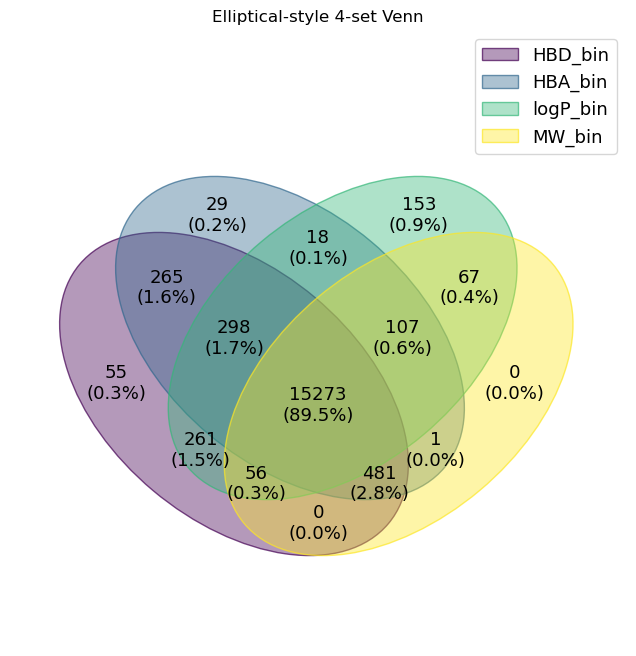

In [65]:
#sets = {c: set(csd_df.index[df[c] == 1]) for c in bin_cols}
sets = {c: set(df.index[df[c] == 1]) for c in bin_cols}
plt.figure(figsize=(8, 8))

v = venn(sets, fmt="{size}\n({percentage:.1f}%)")
plt.title("Elliptical-style 4-set Venn")
plt.show()

We then generate an UpSet plot to visualise the combinations of properties that satisfy the Ro5.

In [67]:
print(df.isna().sum())

identifier    17078
smiles        17078
HBD           17078
HBA           17078
logP          17078
MW            17078
HBD_bin           0
HBA_bin           0
logP_bin          0
MW_bin            0
bin_sum           0
dtype: int64


In [71]:
df.isna().sum()
df[df.isna().any(axis=1)]

,identifier,smiles,HBD,HBA,logP,MW,HBD_bin,HBA_bin,logP_bin,MW_bin,bin_sum
ABABIQ,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,0
ABADOY,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,0
ABAJAQ,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,0
ABAQEB,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,0
ABAZUB,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...
ZZZVZA01,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,0
ZZZVZA02,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,0
ZZZVZA03,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,0
ZZZVZA04,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,0


In [72]:
df.head()

,identifier,smiles,HBD,HBA,logP,MW,HBD_bin,HBA_bin,logP_bin,MW_bin,bin_sum
0,ABABIQ,COc1c(N2CC3[NH2+]CCCC3C2)c(F)cc2C(=O)C(=CN(C3C...,2.0,4.0,1.34430,402.182361,True,True,True,True,4
1,ABADOY,[NH3+]c1ccc(cc1)S(N)(=O)=O,2.0,2.0,-0.79260,173.037925,True,True,True,True,4
2,ABAJAQ,O=S(=O)([O-])c1cccc2c1cccc2S(=O)(=O)[O-],0.0,6.0,0.64800,285.961677,True,True,True,True,4
3,ABAQEB,OC(=O)C1CCCCC1C(=O)[O-],1.0,3.0,-0.37270,171.066282,True,True,True,True,4
4,ABAZUB,COc1cc(Nc2c(cnc3cc(OCCCN4CCN(C)CC4)c(OC)cc23)C...,1.0,8.0,5.19038,529.164745,True,True,False,False,2


c:\Users\teaching\.conda\envs\ccdc3\Lib\site-packages\upsetplot\plotting.py:795: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  styles["linewidth"].fillna(1, inplace=True)
c:\Users\teaching\.conda\envs\ccdc3\Lib\site-packages\upsetplot\plotting.py:796: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series thr

ValueError: Invalid RGBA argument: nan

<Figure size 1000x600 with 0 Axes>

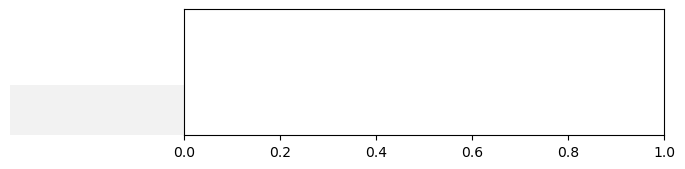

In [80]:
bin_cols = ["HBD_bin", "HBA_bin", "logP_bin", "MW_bin"]

#csd_df[bin_cols] = csd_df[bin_cols].fillna(0).astype(int)
df[bin_cols] = df[bin_cols].fillna(0).astype(int)

#csd_df[bin_cols] = csd_df[bin_cols].fillna(0).astype(bool)
clean_df = df[bin_cols].fillna(0).astype(bool)

#data = from_indicators(bin_cols, csd_df)
data = from_indicators(clean_df)

plt.figure(figsize=(10, 6))
up = UpSet(
    data,
    subset_size="count",
    show_counts=True,
    sort_by="cardinality"
)

up.plot()
plt.suptitle("UpSet plot for properties", y=1.02)
plt.show()